<a href="https://colab.research.google.com/github/logeshwariv24-spec/car-price-prediction/blob/main/download.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loaded!
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  
RMSE     : 0.97
R² Score : 0.96


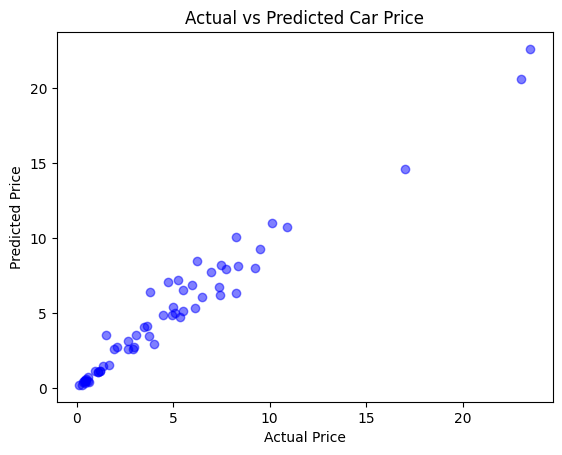

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# 1. Load
df = pd.read_csv('car data .csv')
print("Data Loaded!")
print(df.columns.tolist())  # Column names பாக்கலாம்
print(df.head())

# 2. Clean
df.dropna(inplace=True)
df['Car_Age'] = 2024 - df['Year']
df.drop(['Year','Car_Name'], axis=1, inplace=True)

# 3. Encode
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# 4. Features
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# 5. Split
X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 6. Train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 7. Results
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE     : {rmse:.2f}")
print(f"R² Score : {r2:.2f}")

# 8. Graph
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")
plt.savefig('results.png')
plt.show()